In [ ]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, jaccard_score, roc_auc_score, precision_score, recall_score, f1_score
from typing import List, Tuple, cast
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

## **First Try different models**

In [2]:
ROOT = Path().resolve()
DATA = ROOT.parent  / "content"
CSV_EXPORTS = ROOT / "csv_exports"  # Ruta a los CSV exportados desde preprocessing

# Cargar dataframe para las partes anteriores del notebook (celdas 2-5, 7-8)
# Nota: df_exp_50_variable_selection.csv no existe, así que cargamos df_exp_50.csv
# El código nuevo en la celda 6 carga directamente df_exp_50.csv con timestamp para el análisis temporal
df = pd.read_csv(CSV_EXPORTS / "df_exp_50.csv")

In [3]:
df = df.dropna()
print(df.isnull().sum())

V1                   0
V2                   0
V3                   0
V4                   0
V5                   0
                    ..
device_change        0
browser_change       0
shared_ip            0
amount_log           0
is_outlier_amount    0
Length: 74, dtype: int64


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 74 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   V1                  500000 non-null  float64
 1   V2                  500000 non-null  float64
 2   V3                  500000 non-null  float64
 3   V4                  500000 non-null  float64
 4   V5                  500000 non-null  float64
 5   V6                  500000 non-null  float64
 6   V7                  500000 non-null  float64
 7   V8                  500000 non-null  float64
 8   V9                  500000 non-null  float64
 9   V10                 500000 non-null  float64
 10  V11                 500000 non-null  float64
 11  V12                 500000 non-null  float64
 12  V13                 500000 non-null  float64
 13  V14                 500000 non-null  float64
 14  V15                 500000 non-null  float64
 15  V16                 500000 non-nul

In [25]:
df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,days_in_bank_log,secs_since_prev_tx,tx_per_customer,tx_rate,geo_anomaly,device_change,browser_change,shared_ip,amount_log,is_outlier_amount
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,...,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,-2.007556,1.510345,-2.950170,1.952358,-1.301246,-0.576612,-2.337083,0.176277,-1.085093,-2.406927,...,6.807159,722.449894,286.865773,0.408717,0.996226,0.704872,0.627942,0.000048,3.006500,0.147390
std,5.032039,3.459153,5.784690,3.142104,3.833277,1.709769,5.361456,4.503910,2.214850,4.303252,...,0.646487,1068.445099,16.203057,0.368000,0.061317,0.456101,0.483354,0.006928,1.928811,0.354495
min,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.595578,-73.216718,-13.463927,-24.617036,...,4.827213,-34.976015,238.600161,0.120275,0.000000,0.000000,0.000000,0.000000,-0.066381,0.000000
25%,-2.520732,-0.247747,-4.247899,-0.296265,-1.543614,-1.343536,-2.533859,-0.213191,-1.902149,-3.906839,...,6.439290,151.000000,276.000000,0.189833,1.000000,0.000000,0.000000,0.000000,1.026042,0.000000
50%,-0.677867,0.754318,-1.034436,1.009273,-0.361903,-0.577713,-0.482047,0.125676,-0.539835,-0.596917,...,6.970456,380.946514,287.000000,0.265869,1.000000,1.000000,1.000000,0.000000,2.982647,0.000000
75%,1.105097,2.420765,0.474713,3.756682,0.481906,0.149370,0.321534,0.757672,0.251759,0.092813,...,7.319396,834.009926,298.000000,0.457060,1.000000,1.000000,1.000000,0.000000,4.602555,0.000000
max,2.454930,22.091566,9.382558,16.875344,34.801666,73.301626,120.589494,20.047181,15.594995,23.745136,...,7.594243,19930.000000,335.384950,2.410040,1.000000,1.000000,1.000000,1.000000,10.153941,1.000000


In [4]:
# ==============================================================================
# PART 1: ONE-HOT ENCODING (SPARSE) + LOGISTIC REGRESSION
# ==============================================================================
all_results = []

X = df.drop('Class', axis=1)
y = df['Class']

categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

# Split before transforming to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Definir el ColumnTransformer
# - Numeric: Apply StandardScaler
# - Categorical: Apply OneHotEncoder
# sparse_output=True because RAM colapses otherwise
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=True, handle_unknown='ignore'), categorical_cols)
    ],
    verbose_feature_names_out=False
)

model_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Training
model_lr.fit(X_train, y_train)

# Evaluating
y_pred = model_lr.predict(X_test)
y_proba = model_lr.predict_proba(X_test)[:, 1]

all_results.append({
    "Model": "Logistic Regression (Pipeline/Sparse)",
    "AUC": roc_auc_score(y_test, y_proba),
    "Recall": recall_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred)
})


c:\Users\M6500QC\OneDrive\Escritorio\1º Cuatrimestre\DATA SCIENCE PROJECT\bluetab-uc3m-project-repo\.venv\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 5, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\M6500QC\OneDrive\Escritorio\1º Cuatrimestre\DATA SCIENCE PROJECT\bluetab-uc3m-project-repo\.venv\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 5, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [7]:
# ==============================================================================
# PART 2: LABEL ENCODING + RANDOM FOREST AND XGBOOST
# ==============================================================================
df_le = df.copy()
le = LabelEncoder()
for col in df_le.columns:
    if df_le[col].dtype == 'object':
        df_le[col] = df_le[col].astype(str)
        df_le[col] = le.fit_transform(df_le[col])

X_le = df_le.drop('Class', axis=1)
y_le = df_le['Class']

X_train_le, X_test_le, y_train_le, y_test_le = train_test_split(
    X_le, y_le, test_size=0.2, random_state=42, stratify=y_le
)

tree_models = {
    "Random Forest (Label Enc)": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost (Label Enc)": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Training and evaluating
for name, model in tree_models.items():
    model.fit(X_train_le, y_train_le)

    y_pred = model.predict(X_test_le)
    y_proba = model.predict_proba(X_test_le)[:, 1]

    all_results.append({
        "Model": name,
        "AUC": roc_auc_score(y_test_le, y_proba),
        "Recall": recall_score(y_test_le, y_pred),
        "Precision": precision_score(y_test_le, y_pred),
        "F1": f1_score(y_test_le, y_pred),
        "Accuracy": accuracy_score(y_test_le, y_pred)
    })

KeyboardInterrupt: 

,AUC,Recall,Precision,F1,Accuracy
Model,,,,,
Logistic Regression (Pipeline/Sparse),0.999899,1.000000,0.999283,0.999641,0.999690
Random Forest (Label Enc),1.000000,1.000000,0.999884,0.999942,0.999950
XGBoost (Label Enc),1.000000,1.000000,0.999884,0.999942,0.999950


C:\Users\M6500QC\AppData\Local\Temp\ipykernel_22792\3287010896.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df["F1"], palette="viridis")
C:\Users\M6500QC\AppData\Local\Temp\ipykernel_22792\3287010896.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df["Recall"], palette="magma")


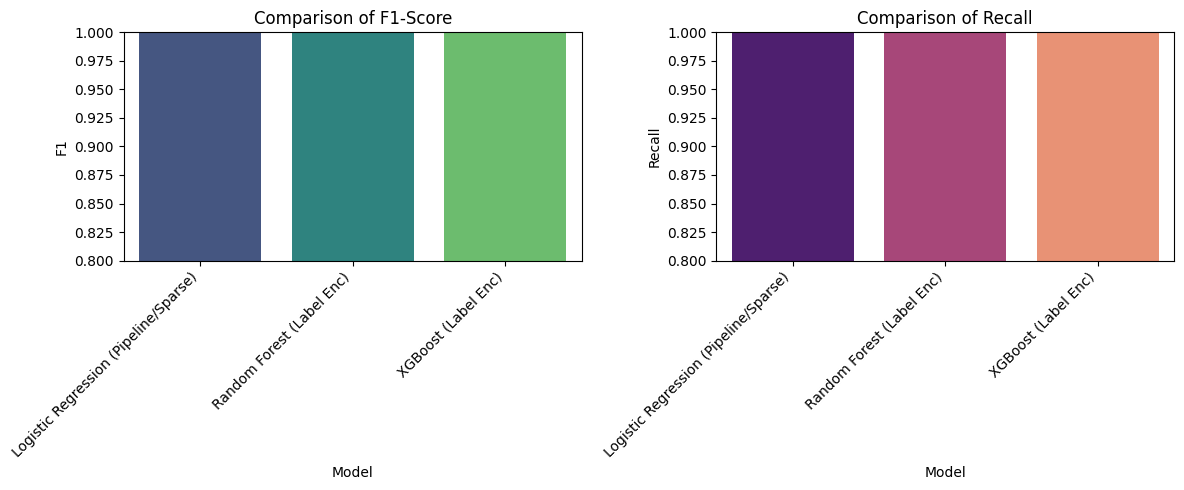

In [ ]:

# ==============================================================================
# PART 3: COMPARISON
# ==============================================================================

# df of results
results_df = pd.DataFrame(all_results).set_index("Model")

# table
display(results_df.style.highlight_max(color='lightgreen', axis=0))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=results_df.index, y=results_df["F1"], palette="viridis")
plt.title("Comparison of F1-Score")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 1.0)

plt.subplot(1, 2, 2)
sns.barplot(x=results_df.index, y=results_df["Recall"], palette="magma")
plt.title("Comparison of Recall")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 1.0)

plt.tight_layout()
plt.show()

## **Temporal Split Model**
- Temporal split
- Feature Selection (only PCA variables)
- Test all datasets with different proportions

Nota sobre el dataset (50/50)

Usamos el dataframe balanceado `df_exp_50.csv` (50% fraud / 50% no fraud) exportado desde `notebooks/csv_exports/`. Ese archivo ya incluye `timestamp` del merge en `preprocessing.ipynb`, así que no rehacemos merges ni derivamos de nuevo las features temporales base; solo convertimos `timestamp` a datetime y extraemos la fecha para el split temporal por día.


Dataframe completo cargado: (500000, 74)
Columnas disponibles: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10']...
✓ Columna 'timestamp' encontrada

=== Análisis de días únicos ===
Número de días únicos: 2

Distribución de transacciones por día:
timestamp
2023-01-01    268188
2023-01-02    231812
Name: count, dtype: int64

=== Balance de clases por día ===

Fecha: 2023-01-01
  Total transacciones: 268188
  Clase 0 (No fraude): 144377
  Clase 1 (Fraude): 123811
  % Fraude: 46.17%

Fecha: 2023-01-02
  Total transacciones: 231812
  Clase 0 (No fraude): 139691
  Clase 1 (Fraude): 92121
  % Fraude: 39.74%

=== Días seleccionados ===
Train date: 2023-01-01
Test date: 2023-01-02

=== Selección de variables PCA ===
Variables PCA disponibles: 28 de 28
Variables: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']

Shape del dataframe PCA: (500000, 

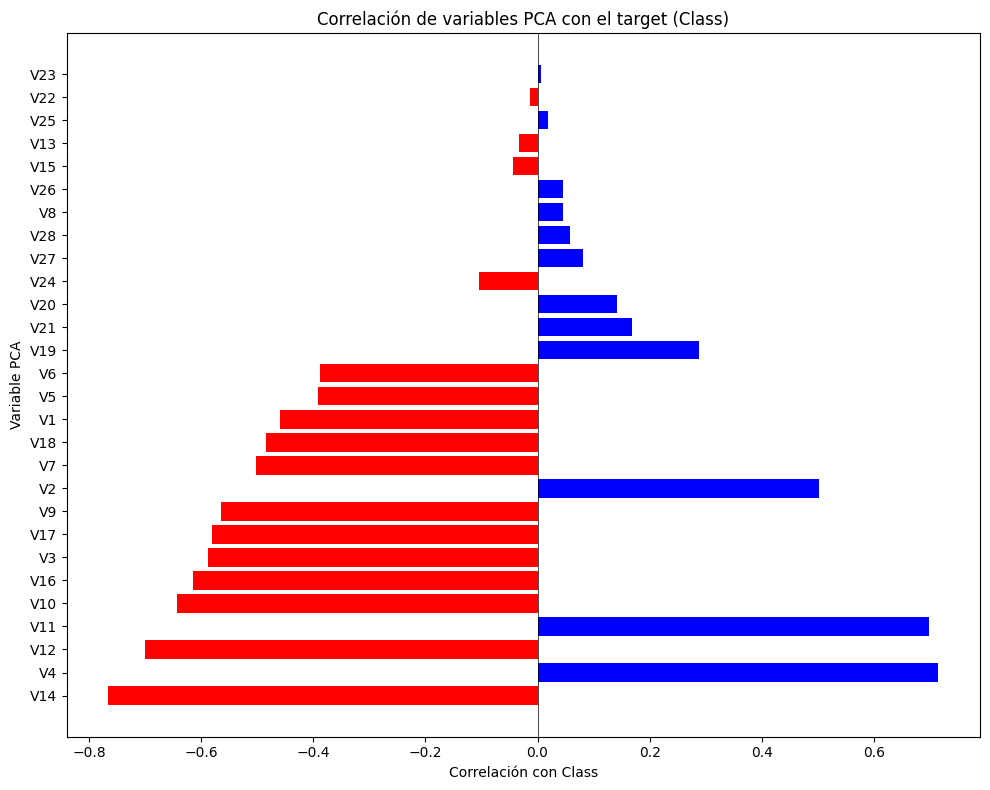


=== Eliminación de variables correlacionadas ===
  Eliminando V1 (corr con target: 0.4595) vs V3 (corr con target: 0.5874)
  Eliminando V2 (corr con target: 0.5029) vs V3 (corr con target: 0.5874)
  Eliminando V5 (corr con target: 0.3910) vs V3 (corr con target: 0.5874)
  Eliminando V7 (corr con target: 0.5020) vs V3 (corr con target: 0.5874)
  Eliminando V3 (corr con target: 0.5874) vs V10 (corr con target: 0.6441)
  Eliminando V12 (corr con target: 0.6998) vs V4 (corr con target: 0.7156)
  Eliminando V4 (corr con target: 0.7156) vs V14 (corr con target: 0.7665)
  Eliminando V9 (corr con target: 0.5643) vs V10 (corr con target: 0.6441)
  Eliminando V10 (corr con target: 0.6441) vs V11 (corr con target: 0.6995)
  Eliminando V11 (corr con target: 0.6995) vs V14 (corr con target: 0.7665)
  Eliminando V17 (corr con target: 0.5816) vs V16 (corr con target: 0.6148)
  Eliminando V18 (corr con target: 0.4846) vs V16 (corr con target: 0.6148)

Variables PCA iniciales: 28
Variables eliminadas 

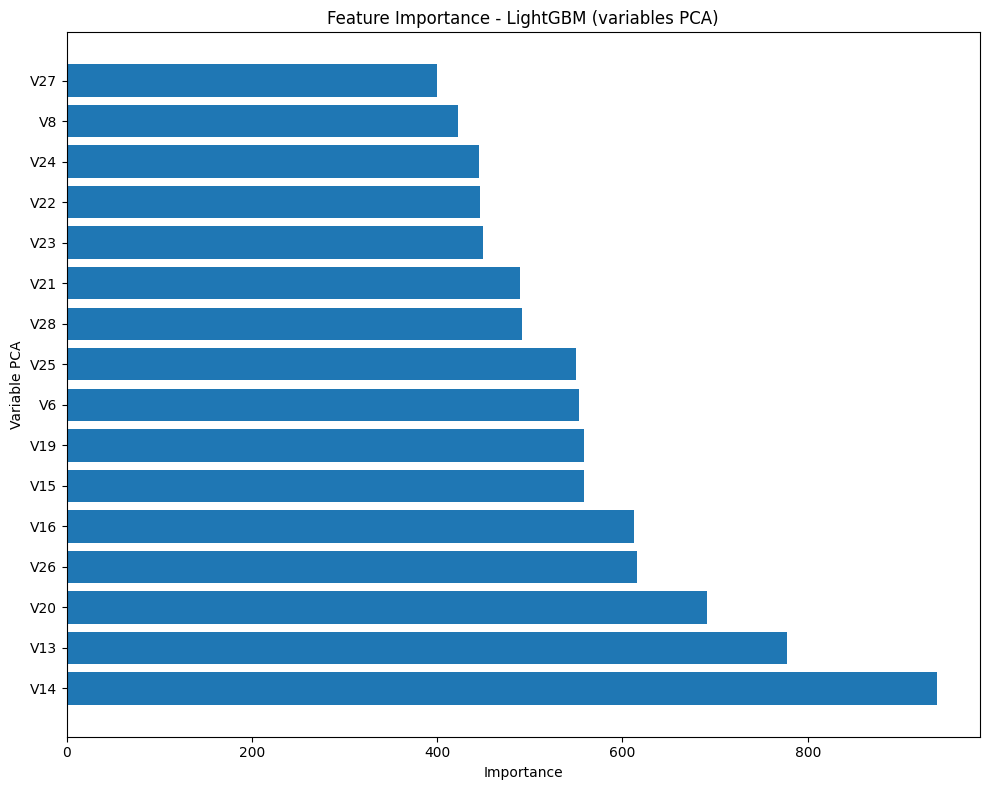

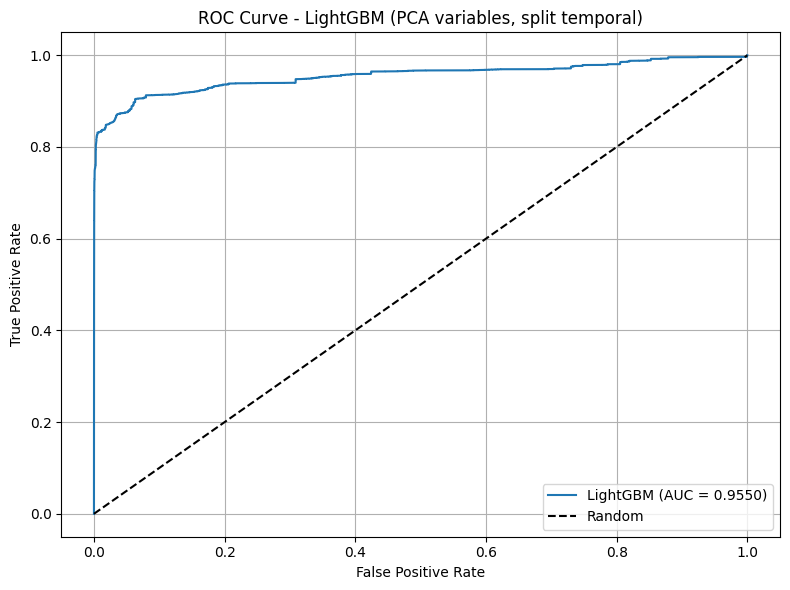


=== Resumen de la implementación ===
✓ Variables PCA iniciales: 28
✓ Variables eliminadas por correlación: 12
✓ Variables PCA finales usadas: 16
✓ Train date: 2023-01-01
✓ Test date: 2023-01-02
✓ Modelo: LightGBM
✓ ROC AUC: 0.9550


In [ ]:
# ==============================================================================
# NUEVA SECCIÓN: Feature Selection y Split Temporal 
# ==============================================================================
"""
Implementación de las mejoras acordadas:
1. Split temporal: train y test cada uno con un día completo
2. Usar solo variables PCA (V1-V28)
3. Eliminar variables correlacionadas
4. Analizar correlaciones con el target
5. Enfocarse en LightGBM (dado que CatBoost parece poco fiable)
"""

from typing import List, Tuple, cast
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


# Cargar el dataframe completo desde preprocessing que ya tiene timestamp
CSV_EXPORTS = Path().resolve() / "csv_exports"
df_full = pd.read_csv(CSV_EXPORTS / "df_exp_50.csv")
print(f"Dataframe completo cargado: {df_full.shape}")
print(f"Columnas disponibles: {list(df_full.columns)[:10]}...")  # Mostrar primeras 10

# Verificar si tiene timestamp (debería tenerlo según preprocessing.ipynb)
if 'timestamp' in df_full.columns:
    print("✓ Columna 'timestamp' encontrada")
    df_work = df_full.copy()
else:
    raise ValueError("df_exp_50.csv no contiene la columna 'timestamp'. Verifica preprocessing/export.")

# =============================
# 1. Análisis de datos temporales
# =============================

ts_series = df_work['timestamp'] if 'timestamp' in df_work.columns else None

if ts_series is not None and bool(ts_series.notna().any()):
    # Convertir timestamp a datetime si es necesario
    ts_series = pd.to_datetime(ts_series, errors='coerce')
    df_work['timestamp'] = ts_series
    
    # Extraer la fecha (día)
    date_series = ts_series.dt.date
    df_work['date'] = date_series
    
    # Analizar días únicos
    unique_dates = pd.Series(date_series).value_counts().sort_index()
    print("\n=== Análisis de días únicos ===")
    print(f"Número de días únicos: {pd.Series(date_series).nunique()}")
    print("\nDistribución de transacciones por día:")
    print(unique_dates.head(10))  # Mostrar primeros 10 días
    
    # Verificar balance de clases por día
    print("\n=== Balance de clases por día ===")
    for date in sorted(pd.Series(date_series).dropna().unique())[:5]:  # Mostrar primeros 5 días
        day_mask = df_work['date'] == date
        day_data = df_work.loc[day_mask]
        class_counts = day_data['Class'].value_counts()
        total_day = len(day_data)
        fraud_count = float(class_counts.get(1, 0))
        print(f"\nFecha: {date}")
        print(f"  Total transacciones: {total_day}")
        print(f"  Clase 0 (No fraude): {class_counts.get(0, 0)}")
        print(f"  Clase 1 (Fraude): {int(fraud_count)}")
        if total_day > 0:
            print(f"  % Fraude: {fraud_count / float(total_day) * 100:.2f}%")
    
    # Seleccionar días para train y test
    sorted_dates = sorted(pd.Series(date_series).dropna().unique())
    if len(sorted_dates) >= 2:
        train_date = sorted_dates[0]  # Primer día para train
        test_date = sorted_dates[1]   # Segundo día para test
        print(f"\n=== Días seleccionados ===")
        print(f"Train date: {train_date}")
        print(f"Test date: {test_date}")
    else:
        print("\n⚠️ ADVERTENCIA: Solo hay un día de datos. No se puede hacer split temporal.")
        train_date = sorted_dates[0] if len(sorted_dates) > 0 else None
        test_date = None
else:
    print("⚠️ ADVERTENCIA: No se encontró la columna 'timestamp' válida en el dataframe.")
    train_date = None
    test_date = None

# =============================
# 2. Selección de variables PCA (V1-V28)
# =============================

print("\n=== Selección de variables PCA ===")

# Verificar qué variables V1-V28 están disponibles
pca_vars = [f'V{i}' for i in range(1, 29)]
available_pca_vars = [var for var in pca_vars if var in df_work.columns]
subset_vars = list(available_pca_vars)

print(f"Variables PCA disponibles: {len(available_pca_vars)} de 28")
print(f"Variables: {available_pca_vars}")

if len(available_pca_vars) == 0:
    raise ValueError("No se encontraron variables PCA (V1-V28) en el dataframe")

# Crear dataframe solo con variables PCA, target y date (si existe)
cols_to_include = subset_vars + ['Class']
if 'date' in df_work.columns:
    cols_to_include.append('date')

df_pca = df_work[cols_to_include].copy()

# Verificar valores faltantes
pca_only: pd.DataFrame = df_pca.loc[:, subset_vars]
missing_pca = pca_only.isnull().sum()
if missing_pca.sum() > 0:
    print(f"\n⚠️ Valores faltantes en variables PCA:")
    print(missing_pca[missing_pca > 0])
    # Eliminar filas con valores faltantes
    df_pca = df_pca.dropna(subset=subset_vars)
    pca_only = df_pca.loc[:, subset_vars]
    print(f"Filas después de eliminar NaN: {len(df_pca)}")

print(f"\nShape del dataframe PCA: {df_pca.shape}")

# =============================
# 3. Análisis de correlaciones entre variables PCA
# =============================

print("\n=== Análisis de correlaciones entre variables PCA ===")

# Calcular matriz de correlación
corr_matrix: pd.DataFrame = pca_only.corr().abs()

# Identificar pares de variables altamente correlacionadas
threshold = 0.8  # Threshold para considerar alta correlación
high_corr_pairs: List[Tuple[str, str, float]] = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] >= threshold:  # type: ignore
            high_corr_pairs.append((
                str(corr_matrix.columns[i]),
                str(corr_matrix.columns[j]),
                float(corr_matrix.iloc[i, j])
            ))

print(f"\nPares de variables con correlación >= {threshold}: {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print("\nPares altamente correlacionados:")
    for var1, var2, corr_val in high_corr_pairs[:10]:  # Mostrar primeros 10
        print(f"  {var1} <-> {var2}: {corr_val:.4f}")

# =============================
# 4. Correlaciones con el target
# =============================

print("\n=== Correlaciones con el target (Class) ===")

# Calcular correlación de cada variable PCA con Class
corr_with_target: pd.DataFrame = df_pca.loc[:, subset_vars + ['Class']].corr()
target_corr = corr_with_target['Class'].drop('Class')
target_corr_abs = target_corr.abs().sort_values(ascending=False)

print("\nCorrelaciones con Class (ordenadas por magnitud absoluta):")
print(target_corr_abs.to_frame('Correlation_with_Class'))

# Visualizar correlaciones con el target
plt.figure(figsize=(10, 8))
target_corr_sorted = target_corr.reindex(target_corr_abs.index)
target_corr_sorted_values: np.ndarray = target_corr_sorted.to_numpy(dtype=float)

colors = ['red' if x < 0 else 'blue' for x in target_corr_sorted_values]

yticks_positions = np.arange(len(target_corr_sorted_values))
yticks_labels: List[str] = [str(idx) for idx in target_corr_sorted.index]

plt.barh(yticks_positions, target_corr_sorted_values, color=colors)
plt.yticks(yticks_positions, yticks_labels)
plt.xlabel('Correlación con Class')
plt.ylabel('Variable PCA')
plt.title('Correlación de variables PCA con el target (Class)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

# =============================
# 5. Eliminar variables correlacionadas
# =============================
print("\n=== Eliminación de variables correlacionadas ===")

vars_to_remove: set[str] = set()
vars_considered: set[str] = set(available_pca_vars)  # las que seguimos “vivas”

for var1, var2, corr_val in high_corr_pairs:
    # Si alguna de las dos ya está eliminada, saltamos este par
    if var1 in vars_to_remove or var2 in vars_to_remove:
        continue

    corr1_with_target = abs(float(target_corr[var1]))
    corr2_with_target = abs(float(target_corr[var2]))
    
    if corr1_with_target >= corr2_with_target:
        # Nos quedamos con var1, eliminamos var2
        vars_to_remove.add(var2)
        print(
            f"  Eliminando {var2} (corr con target: {corr2_with_target:.4f}) "
            f"vs {var1} (corr con target: {corr1_with_target:.4f})"
        )
    else:
        # Nos quedamos con var2, eliminamos var1
        vars_to_remove.add(var1)
        print(
            f"  Eliminando {var1} (corr con target: {corr1_with_target:.4f}) "
            f"vs {var2} (corr con target: {corr2_with_target:.4f})"
        )

final_pca_vars = [var for var in available_pca_vars if var not in vars_to_remove]

print(f"\nVariables PCA iniciales: {len(available_pca_vars)}")
print(f"Variables eliminadas por correlación: {len(vars_to_remove)}")
print(f"Variables PCA finales: {len(final_pca_vars)}")
print(f"Variables finales: {final_pca_vars}")

# Actualizar dataframe con solo las variables seleccionadas
cols_final = final_pca_vars + ['Class']
if 'date' in df_pca.columns:
    cols_final.append('date')
df_pca_final = df_pca[cols_final].copy()

# =============================
# 6. Split temporal por día
# =============================

print("\n=== Split temporal por día ===")

if train_date is not None and test_date is not None and 'date' in df_pca_final.columns:
    # Split por día
    train_mask = df_pca_final['date'] == train_date
    test_mask = df_pca_final['date'] == test_date
    
    X_train_temp = df_pca_final.loc[train_mask, final_pca_vars].copy()
    y_train_temp = df_pca_final.loc[train_mask, 'Class'].copy()
    
    X_test_temp = df_pca_final.loc[test_mask, final_pca_vars].copy()
    y_test_temp = df_pca_final.loc[test_mask, 'Class'].copy()
    
    print(f"Train set - Día: {train_date}")
    print(f"  Shape: {X_train_temp.shape}")
    print(f"  Clase 0: {(y_train_temp == 0).sum()}")
    print(f"  Clase 1: {(y_train_temp == 1).sum()}")
    if len(y_train_temp) > 0:  # type: ignore
        print(f"  % Fraude: {(y_train_temp == 1).sum() / len(y_train_temp) * 100:.2f}%")  # type: ignore
    
    print(f"\nTest set - Día: {test_date}")
    print(f"  Shape: {X_test_temp.shape}")
    print(f"  Clase 0: {(y_test_temp == 0).sum()}")
    print(f"  Clase 1: {(y_test_temp == 1).sum()}")
    if len(y_test_temp) > 0:  # type: ignore
        print(f"  % Fraude: {(y_test_temp == 1).sum() / len(y_test_temp) * 100:.2f}%")  # type: ignore
    
    # SIN SMOTE: usamos directamente el train original
    print("\n=== Train set sin SMOTE ===")
    print(y_train_temp.value_counts())
    X_train_res_temp = X_train_temp
    y_train_res_temp = y_train_temp
    
else:
    print("No se pudo hacer split temporal. Usando split aleatorio como fallback.")
    X_all = df_pca_final.loc[:, final_pca_vars].copy()
    y_all = df_pca_final.loc[:, 'Class'].copy()

    split_result = train_test_split(
        X_all,
        y_all,
        test_size=0.2,
        random_state=42,
        stratify=y_all,
    )
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = cast(
        Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series],
        split_result,
    )
    
    # SIN SMOTE también aquí
    print("\n=== Train set sin SMOTE (split aleatorio) ===")
    print(y_train_temp.value_counts())
    X_train_res_temp = X_train_temp
    y_train_res_temp = y_train_temp

# =============================
# 7. Entrenamiento con LightGBM
# =============================

print("\n=== Entrenamiento con LightGBM (solo variables PCA filtradas) ===")

# Entrenar LightGBM
lgb_model_pca = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42,
    verbose=-1
)

print("Entrenando modelo...")
lgb_model_pca.fit(X_train_res_temp, y_train_res_temp)

# Predicciones
y_pred_lgb_pca = lgb_model_pca.predict(X_test_temp)
y_proba_lgb_pca = lgb_model_pca.predict_proba(X_test_temp)[:, 1]  # type: ignore

# Métricas
print("\n===== LightGBM (PCA variables, split temporal) =====")
print(classification_report(y_test_temp, y_pred_lgb_pca))  # type: ignore
print(f"ROC AUC: {roc_auc_score(y_test_temp, y_proba_lgb_pca):.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test_temp, y_pred_lgb_pca)  # type: ignore
print("\nMatriz de confusión:")
print(cm)

# Feature importance
feature_importance_pca = pd.Series(
    lgb_model_pca.feature_importances_,
    index=final_pca_vars
).sort_values(ascending=False)

print("\n=== Feature Importance (Top 10) ===")
print(feature_importance_pca.head(10))

# Visualizar feature importance
plt.figure(figsize=(10, 8))
fi_values: np.ndarray = feature_importance_pca.to_numpy(dtype=float)
fi_positions = np.arange(len(fi_values))
fi_labels: List[str] = [str(idx) for idx in feature_importance_pca.index]

plt.barh(fi_positions, fi_values)
plt.yticks(fi_positions, fi_labels)
plt.xlabel('Importance')
plt.ylabel('Variable PCA')
plt.title('Feature Importance - LightGBM (variables PCA)')
plt.tight_layout()
plt.show()

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test_temp, y_proba_lgb_pca)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {roc_auc_score(y_test_temp, y_proba_lgb_pca):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM (PCA variables, split temporal)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n=== Resumen de la implementación ===")
print(f"✓ Variables PCA iniciales: {len(available_pca_vars)}")
print(f"✓ Variables eliminadas por correlación: {len(vars_to_remove)}")
print(f"✓ Variables PCA finales usadas: {len(final_pca_vars)}")
if train_date is not None and test_date is not None:
    print(f"✓ Train date: {train_date}")
    print(f"✓ Test date: {test_date}")
print(f"✓ Modelo: LightGBM")
print(f"✓ ROC AUC: {roc_auc_score(y_test_temp, y_proba_lgb_pca):.4f}")



######################################################################
Evaluando: df_exp_50.csv
######################################################################

Análisis detallado: df_exp_50.csv

--- Matriz de Confusión (threshold=0.5) ---
                Predicho
              No Fraude  Fraude
Real No Fraude    135031     103
     Fraude         18315   73146

--- Métricas con threshold=0.5 ---
Recall Fraude:     0.7998 (73146/91461 fraudes detectados)
Precision Fraude:  0.9986 (73146/73249 alertas son fraude)
Recall No Fraude:  0.9992
F1 Fraude:         0.8882

--- Curva Precision-Recall ---
AUC-PR: 0.9753 (más informativo que ROC-AUC para desbalance extremo)
ROC-AUC: 0.9753

--- Threshold Óptimo (maximiza F1 de fraude) ---
Threshold: 0.0002
F1 Fraude: 0.9324
Fraudes detectados: 84497/91461 (Recall: 0.9239)
Falsos positivos: 5286
Precision: 0.9411

--- Matriz de Confusión (threshold óptimo) ---
                Predicho
              No Fraude  Fraude
Real No Fraude    129848

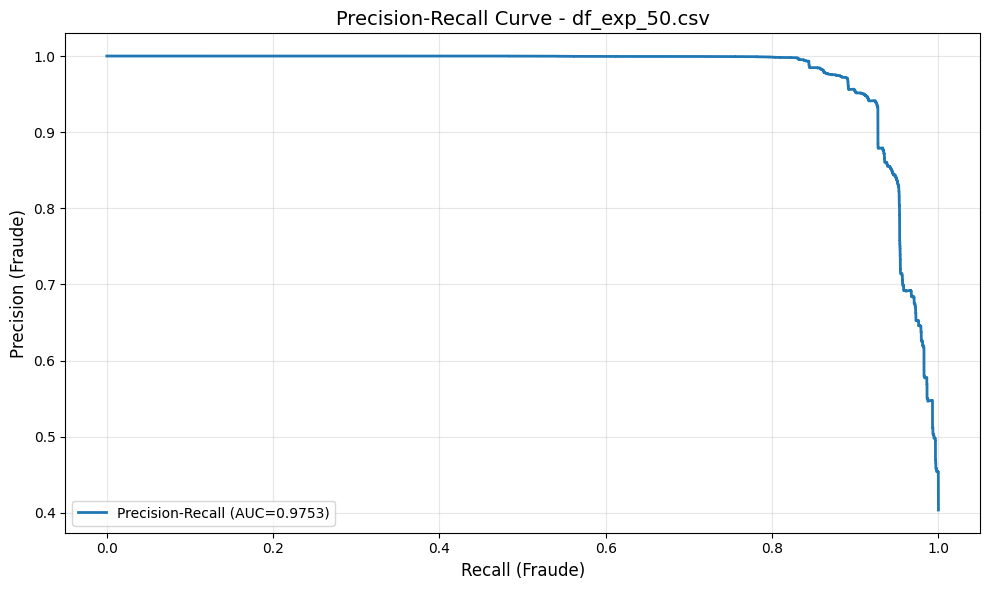

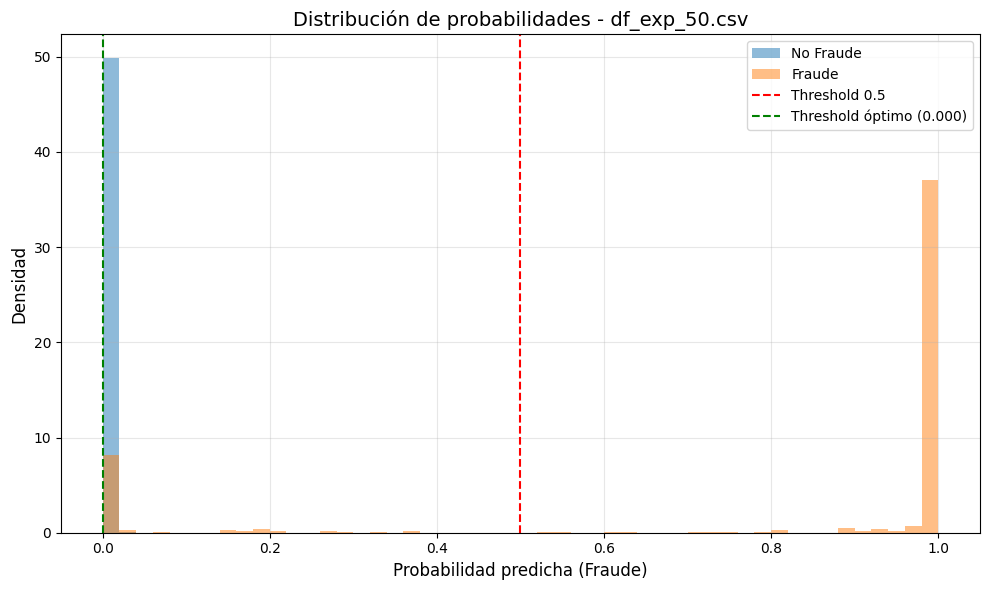


Distribución test: {0: 135134, 1: 91461}
Fraudes en test: 91461 (40.36%)

######################################################################
Evaluando: df_exp_63.csv
######################################################################

Análisis detallado: df_exp_63.csv

--- Matriz de Confusión (threshold=0.5) ---
                Predicho
              No Fraude  Fraude
Real No Fraude    159272     117
     Fraude         13600   56997

--- Métricas con threshold=0.5 ---
Recall Fraude:     0.8074 (56997/70597 fraudes detectados)
Precision Fraude:  0.9980 (56997/57114 alertas son fraude)
Recall No Fraude:  0.9993
F1 Fraude:         0.8926

--- Curva Precision-Recall ---
AUC-PR: 0.9676 (más informativo que ROC-AUC para desbalance extremo)
ROC-AUC: 0.9775

--- Threshold Óptimo (maximiza F1 de fraude) ---
Threshold: 0.0006
F1 Fraude: 0.9191
Fraudes detectados: 62203/70597 (Recall: 0.8811)
Falsos positivos: 2560
Precision: 0.9605

--- Matriz de Confusión (threshold óptimo) ---
       

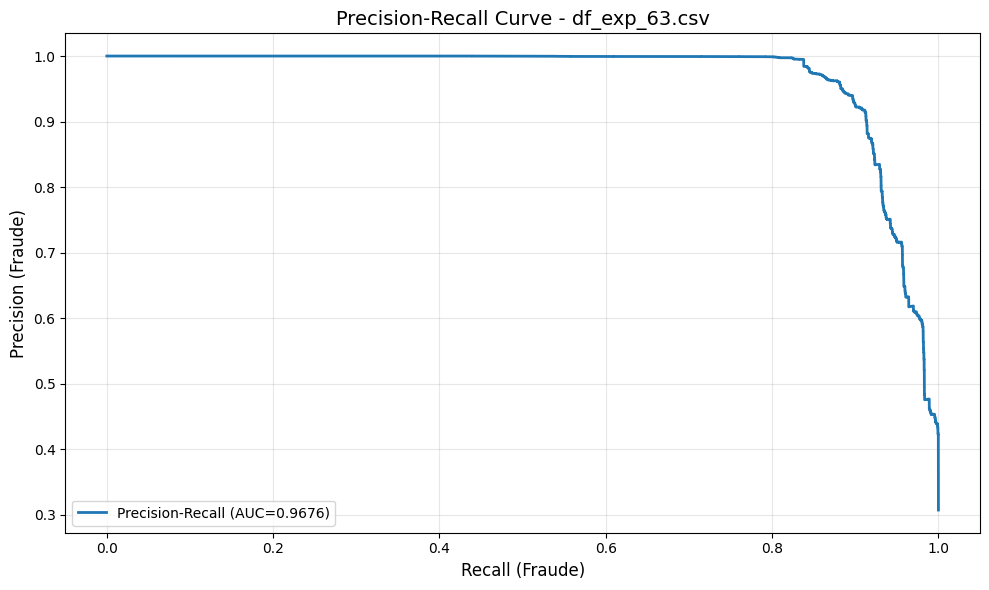

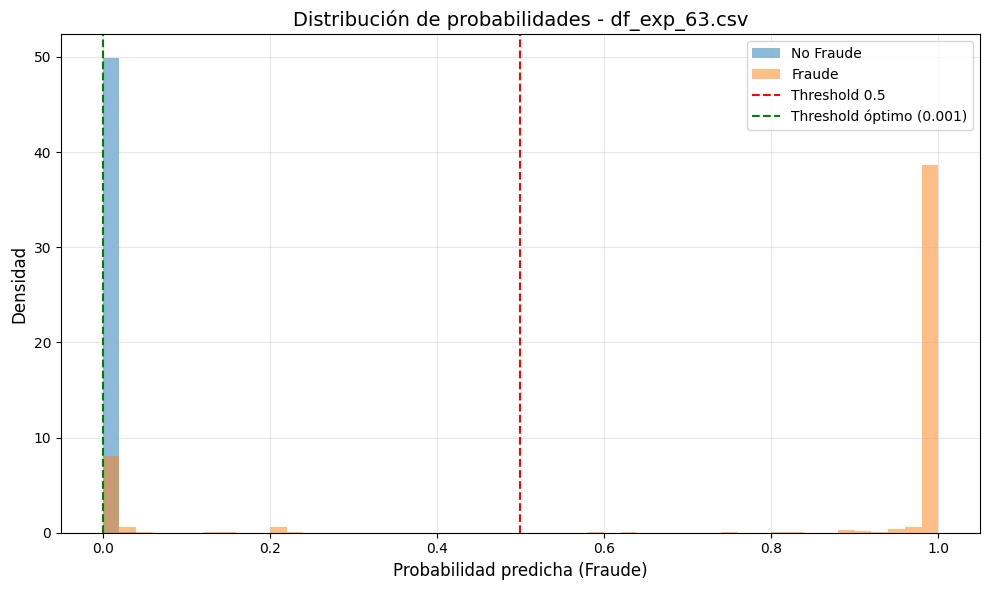


Distribución test: {0: 159389, 1: 70597}
Fraudes en test: 70597 (30.70%)

######################################################################
Evaluando: df_exp_same_prop.csv
######################################################################

Análisis detallado: df_exp_same_prop.csv

--- Matriz de Confusión (threshold=0.5) ---
                Predicho
              No Fraude  Fraude
Real No Fraude    239896     117
     Fraude           203     627

--- Métricas con threshold=0.5 ---
Recall Fraude:     0.7554 (627/830 fraudes detectados)
Precision Fraude:  0.8427 (627/744 alertas son fraude)
Recall No Fraude:  0.9995
F1 Fraude:         0.7967

--- Curva Precision-Recall ---
AUC-PR: 0.8103 (más informativo que ROC-AUC para desbalance extremo)
ROC-AUC: 0.9751

--- Threshold Óptimo (maximiza F1 de fraude) ---
Threshold: 0.8400
F1 Fraude: 0.8023
Fraudes detectados: 619/830 (Recall: 0.7458)
Falsos positivos: 94
Precision: 0.8682

--- Matriz de Confusión (threshold óptimo) ---
       

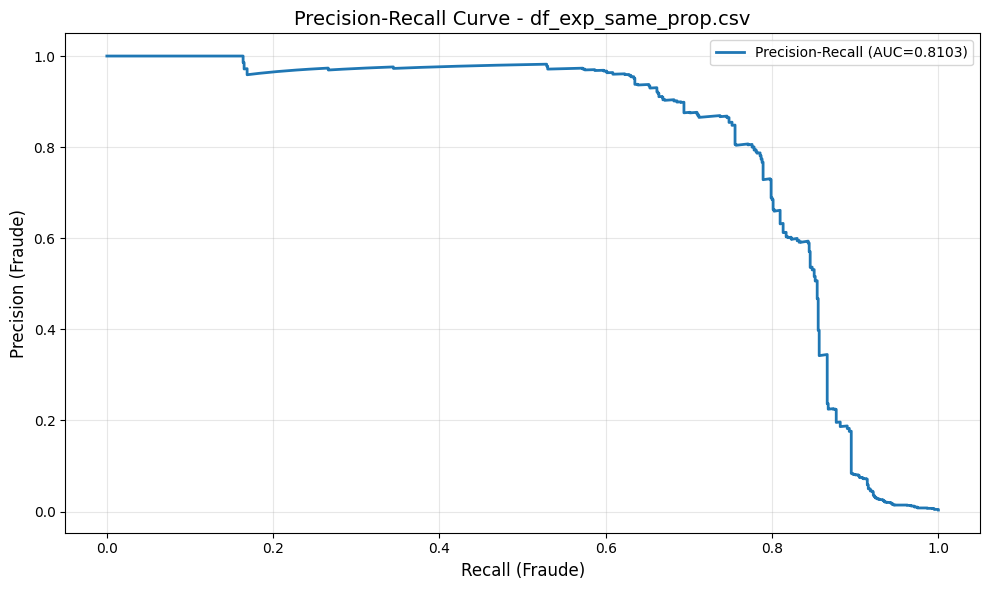

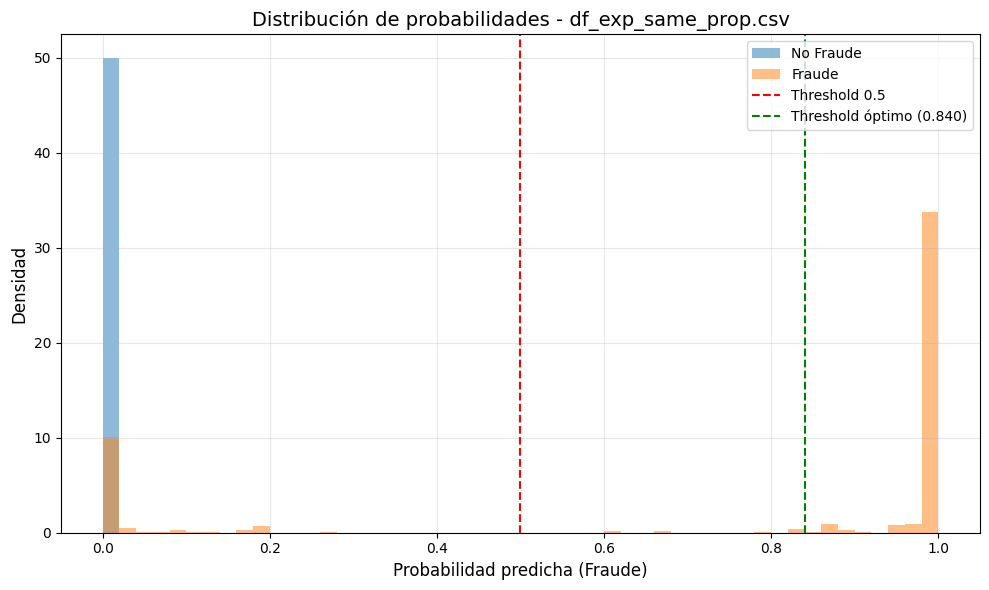


Distribución test: {0: 240013, 1: 830}
Fraudes en test: 830 (0.34%)

######################################################################
Evaluando: df_exp_random.csv
######################################################################

Análisis detallado: df_exp_random.csv

--- Matriz de Confusión (threshold=0.5) ---
                Predicho
              No Fraude  Fraude
Real No Fraude    239392     137
     Fraude           213     673

--- Métricas con threshold=0.5 ---
Recall Fraude:     0.7596 (673/886 fraudes detectados)
Precision Fraude:  0.8309 (673/810 alertas son fraude)
Recall No Fraude:  0.9994
F1 Fraude:         0.7936

--- Curva Precision-Recall ---
AUC-PR: 0.8093 (más informativo que ROC-AUC para desbalance extremo)
ROC-AUC: 0.9751

--- Threshold Óptimo (maximiza F1 de fraude) ---
Threshold: 0.3675
F1 Fraude: 0.8002
Fraudes detectados: 687/886 (Recall: 0.7754)
Falsos positivos: 144
Precision: 0.8267

--- Matriz de Confusión (threshold óptimo) ---
                P

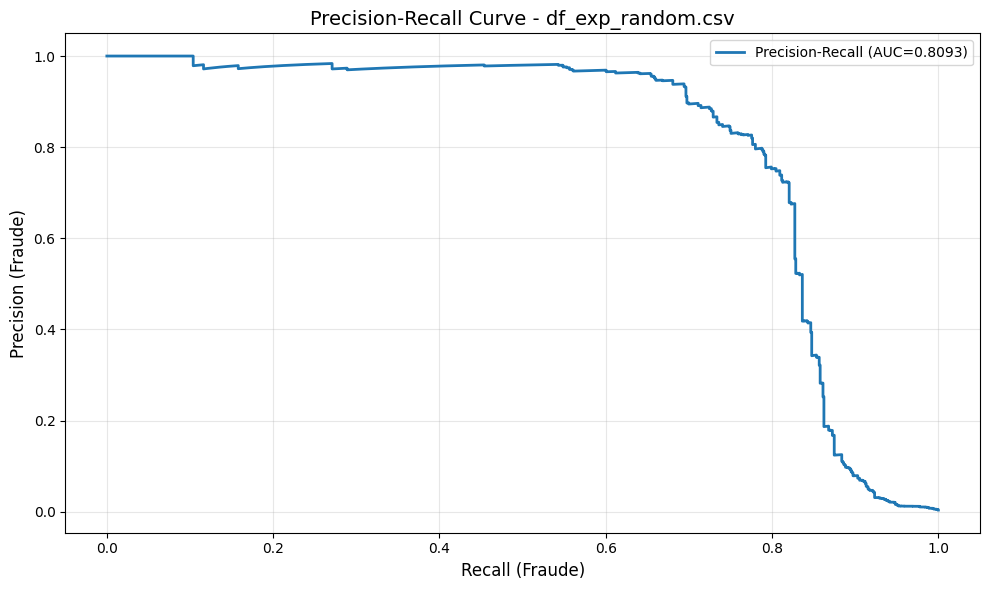

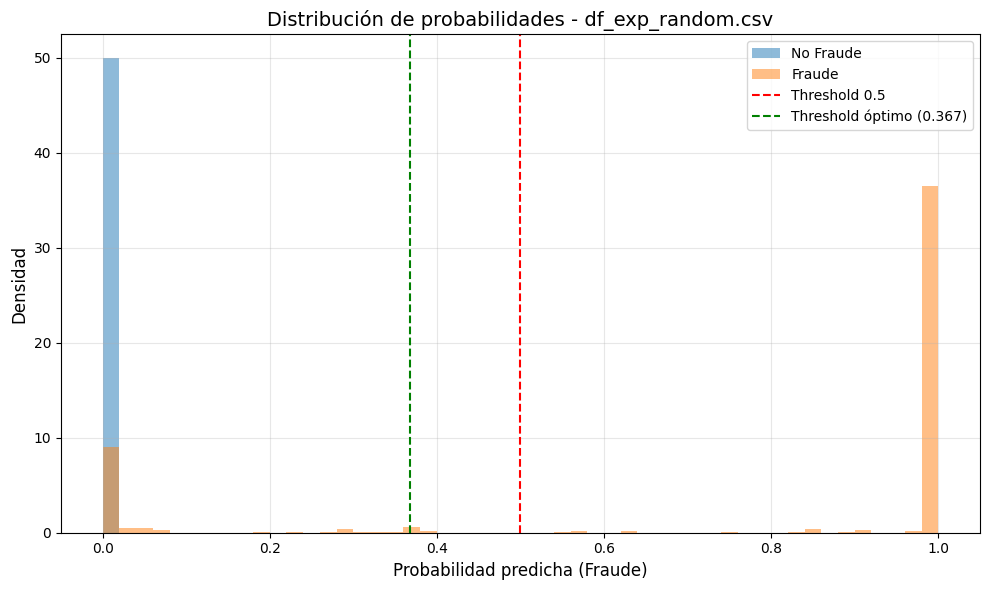


Distribución test: {0: 239529, 1: 886}
Fraudes en test: 886 (0.37%)

######################################################################
Evaluando: df_original.csv
######################################################################

Análisis detallado: df_original.csv

--- Matriz de Confusión (threshold=0.5) ---
                Predicho
              No Fraude  Fraude
Real No Fraude    134920     214
     Fraude            82     116

--- Métricas con threshold=0.5 ---
Recall Fraude:     0.5859 (116/198 fraudes detectados)
Precision Fraude:  0.3515 (116/330 alertas son fraude)
Recall No Fraude:  0.9984
F1 Fraude:         0.4394

--- Curva Precision-Recall ---
AUC-PR: 0.3290 (más informativo que ROC-AUC para desbalance extremo)
ROC-AUC: 0.7952

--- Threshold Óptimo (maximiza F1 de fraude) ---
Threshold: 1.0000
F1 Fraude: 0.5190
Fraudes detectados: 109/198 (Recall: 0.5505)
Falsos positivos: 113
Precision: 0.4910

--- Matriz de Confusión (threshold óptimo) ---
                Predi

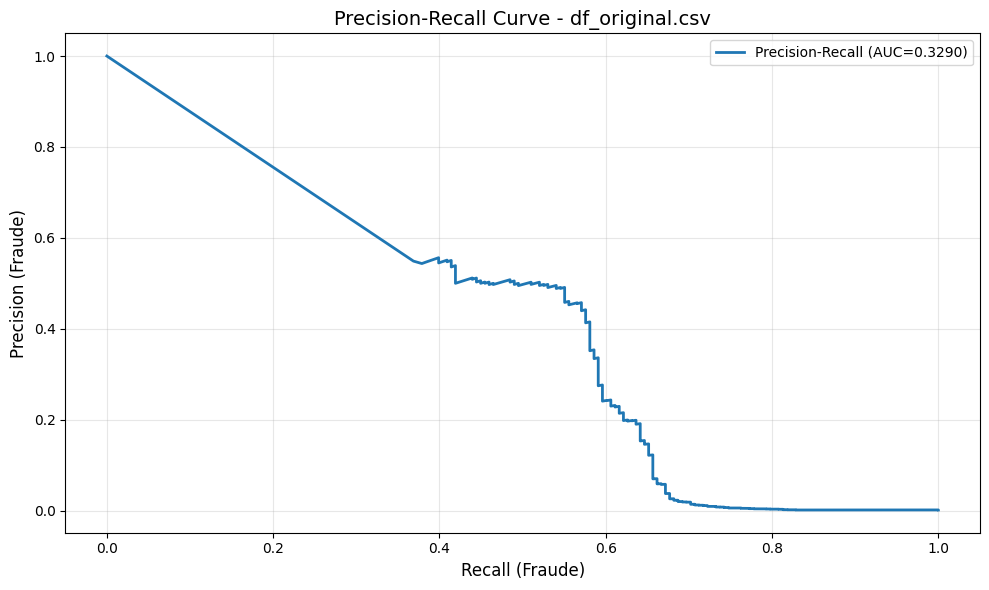

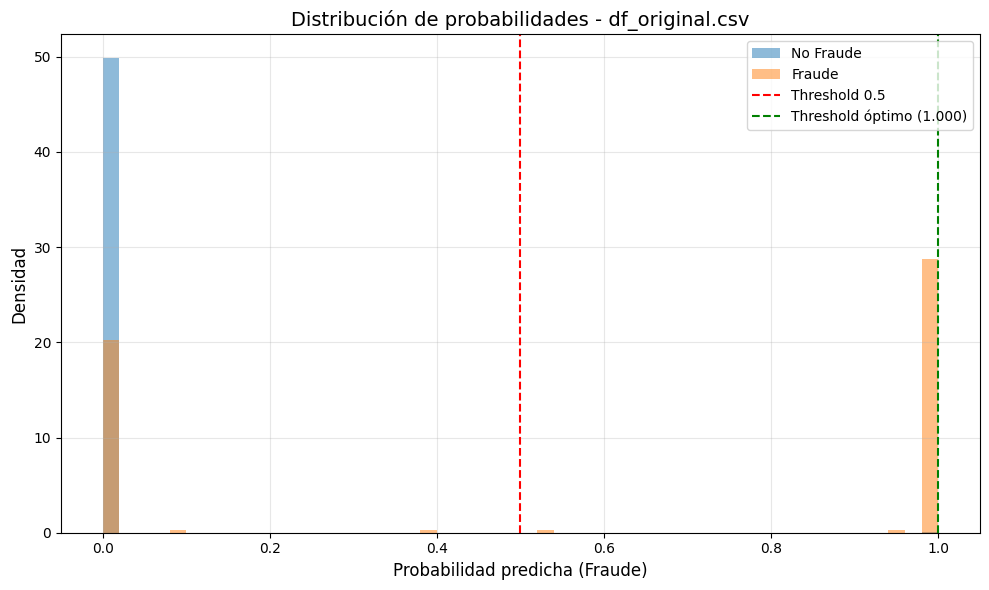


Distribución test: {0: 135134, 1: 198}
Fraudes en test: 198 (0.15%)

COMPARACIÓN DE TODOS LOS DATASETS SINTÉTICOS

--- Métricas con threshold=0.5 ---
                       roc_auc    auc_pr  recall_fraude_05  \
dataset                                                      
df_exp_50.csv         0.975279  0.975341          0.799751   
df_exp_63.csv         0.977474  0.967641          0.807357   
df_exp_same_prop.csv  0.975069  0.810260          0.755422   
df_exp_random.csv     0.975078  0.809298          0.759594   
df_original.csv       0.795190  0.329020          0.585859   

                      precision_fraude_05  f1_fraude_05  
dataset                                                  
df_exp_50.csv                    0.998594      0.888179  
df_exp_63.csv                    0.997951      0.892593  
df_exp_same_prop.csv             0.842742      0.796696  
df_exp_random.csv                0.830864      0.793632  
df_original.csv                  0.351515      0.439394  

--- Mét

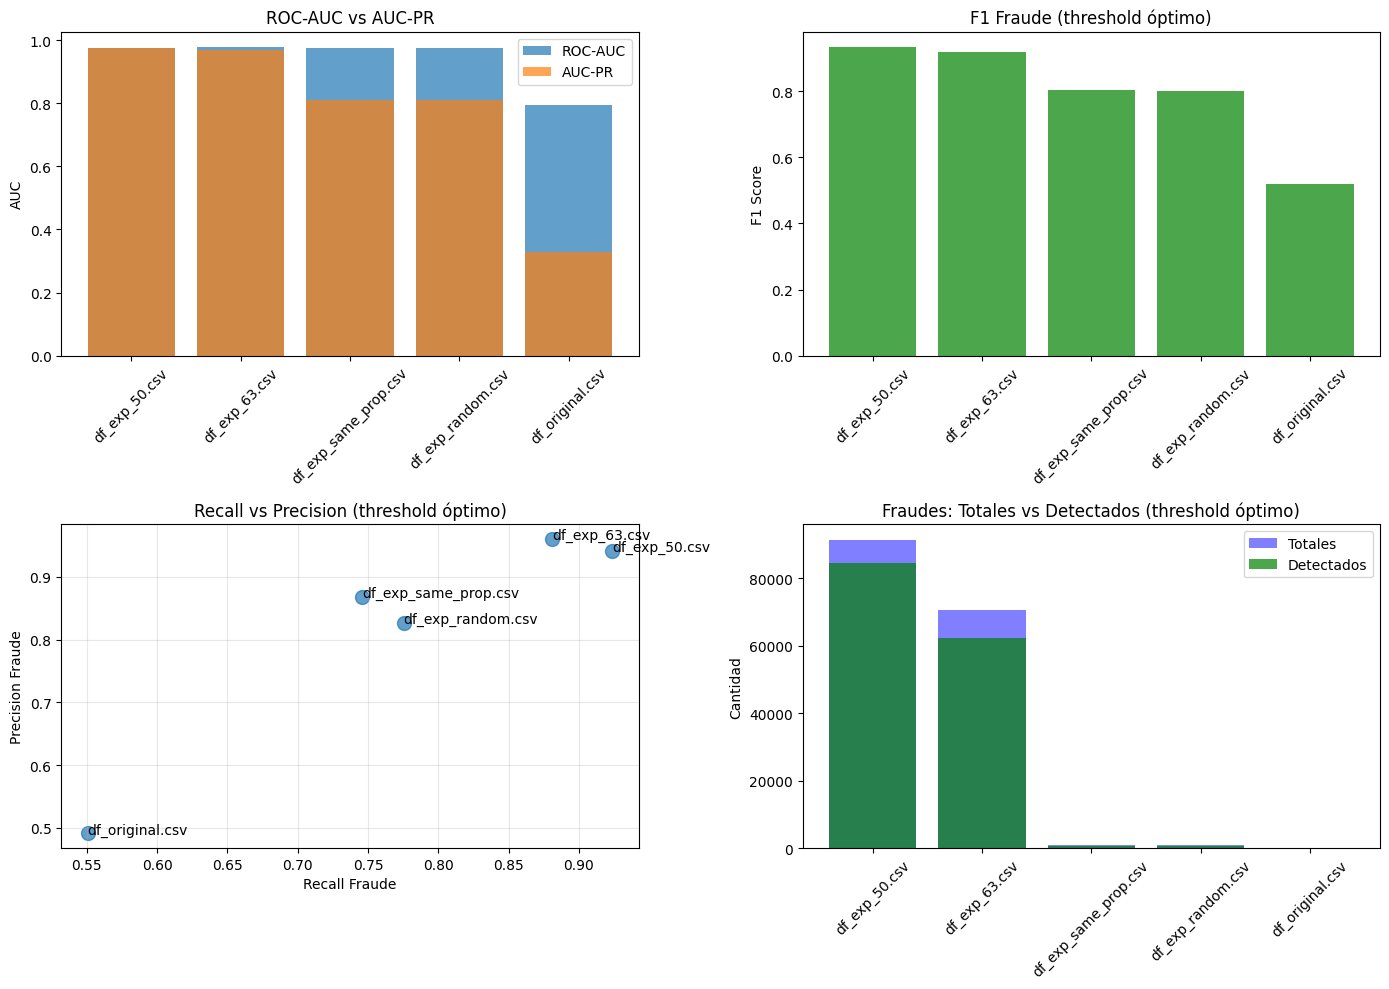


--- RESUMEN: ¿Cuál dataset funciona mejor? ---
Mejor AUC-PR: df_exp_50.csv (0.9753)
Mejor F1 Fraude (óptimo): df_exp_50.csv (0.9324)
Mejor Recall Fraude (óptimo): df_exp_50.csv (0.9239)
Mejor Precision Fraude (óptimo): df_exp_63.csv (0.9605)


In [ ]:
# ============================================================================
# Análisis detallado con métricas apropiadas para desbalance extremo
# Evaluación de TODOS los datasets sintéticos (requisito del proyecto)
# ============================================================================
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    roc_auc_score,
)
import numpy as np

def eval_desbalanceado_detallado(df_in: pd.DataFrame, name: str) -> dict:
    """Evalúa con métricas apropiadas para datasets extremadamente desbalanceados.
    - Split temporal día 1 / día 2
    - Usa solo variables PCA (V1-V28)
    - Elimina variables PCA muy correlacionadas entre sí
      quedándose con la más correlacionada con el target.
    Retorna diccionario con métricas clave para comparación.
    """
    print(f"\n{'='*60}")
    print(f"Análisis detallado: {name}")
    print(f"{'='*60}")
    
    df_local = df_in.copy()
    
    # ---------------------------------------------------------------------
    # Timestamp -> date
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No hay timestamp; se omite.")
        return {}
    
    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date
    
    # ---------------------------------------------------------------------
    # 1) Selección inicial de variables PCA (V1-V28)
    # ---------------------------------------------------------------------
    pca_vars = [f"V{i}" for i in range(1, 29)]
    available_pca_vars = [v for v in pca_vars if v in df_local.columns]
    if not available_pca_vars:
        print("No hay V1-V28; se omite.")
        return {}
    
    print(f"Variables PCA disponibles: {len(available_pca_vars)} -> {available_pca_vars}")
    
    # Eliminar filas con NaN en las PCA o en Class
    df_local = df_local.dropna(subset=available_pca_vars + ['Class'])
    
    # ---------------------------------------------------------------------
    # 2) Split temporal (día 1 para train, día 2 para test)
    # ---------------------------------------------------------------------
    dates = sorted([d for d in df_local['date'].dropna().unique()])
    if len(dates) < 2:
        print("Solo hay un día; no se evalúa.")
        return {}
    
    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")
    
    train_df = df_local.loc[df_local['date'] == train_date].copy()
    test_df = df_local.loc[df_local['date'] == test_date].copy()
    
    # ---------------------------------------------------------------------
    # 3) Análisis de correlaciones entre PCA y con el target
    # ---------------------------------------------------------------------
    print("\n=== Análisis de correlaciones entre variables PCA ===")
    pca_only_train: pd.DataFrame = train_df.loc[:, available_pca_vars]
    
    # Matriz de correlación absoluta entre PCA
    corr_matrix: pd.DataFrame = pca_only_train.corr().abs()
    
    # Pares de variables muy correlacionadas
    threshold_corr = 0.8
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] >= threshold_corr:
                high_corr_pairs.append(
                    (corr_matrix.columns[i], corr_matrix.columns[j], float(corr_matrix.iloc[i, j]))
                )
    print(f"Pares de variables con correlación >= {threshold_corr}: {len(high_corr_pairs)}")
    
    # Correlaciones con el target (Class) en TRAIN
    corr_with_target = train_df[available_pca_vars + ['Class']].corr()
    target_corr = corr_with_target['Class'].drop('Class')
    
    print("\nCorrelaciones con Class (ordenadas por |correlación|):")
    print(target_corr.abs().sort_values(ascending=False).to_frame("Correlation_with_Class"))
    
    # ---------------------------------------------------------------------
    # 4) Eliminar PCA muy correlacionadas entre sí
    #    Mantener siempre la que tenga mayor |correlación| con Class
    # ---------------------------------------------------------------------
    print("\n=== Eliminación de variables PCA altamente correlacionadas ===")
    vars_to_remove: set[str] = set()
    
    for var1, var2, corr_val in high_corr_pairs:
        # Si alguna ya fue eliminada en un paso anterior, saltamos el par
        if var1 in vars_to_remove or var2 in vars_to_remove:
            continue
        
        corr1_with_target = abs(float(target_corr[var1]))
        corr2_with_target = abs(float(target_corr[var2]))
        
        if corr1_with_target >= corr2_with_target:
            # Nos quedamos con var1, eliminamos var2
            vars_to_remove.add(var2)
            print(
                f"  Eliminando {var2} (|corr target|={corr2_with_target:.4f}) "
                f"vs {var1} (|corr target|={corr1_with_target:.4f})  [corr {corr_val:.4f}]"
            )
        else:
            vars_to_remove.add(var1)
            print(
                f"  Eliminando {var1} (|corr target|={corr1_with_target:.4f}) "
                f"vs {var2} (|corr target|={corr2_with_target:.4f})  [corr {corr_val:.4f}]"
            )
    
    final_pca_vars = [v for v in available_pca_vars if v not in vars_to_remove]
    
    print(f"\nVariables PCA iniciales: {len(available_pca_vars)}")
    print(f"Variables eliminadas por alta correlación: {len(vars_to_remove)} -> {sorted(list(vars_to_remove))}")
    print(f"Variables PCA finales usadas: {len(final_pca_vars)} -> {final_pca_vars}")
    
    if not final_pca_vars:
        print("No queda ninguna variable PCA tras la filtración; se omite.")
        return {}
    
    # ---------------------------------------------------------------------
    # 5) Desduplicar usando SOLO las PCA finales
    # ---------------------------------------------------------------------
    train_df = train_df.drop_duplicates(subset=final_pca_vars)
    test_df = test_df.drop_duplicates(subset=final_pca_vars)
    
    X_train = train_df[final_pca_vars]
    y_train = train_df['Class']
    X_test = test_df[final_pca_vars]
    y_test = test_df['Class']
    
    print(f"\nShape train: {X_train.shape} | Shape test: {X_test.shape}")
    
    # ---------------------------------------------------------------------
    # 6) Entrenar modelo LightGBM (sin SMOTE)
    # ---------------------------------------------------------------------
    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42,
        verbose=-1,
    )
    model.fit(X_train, y_train)
    
    # Predicciones con probabilidades
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # ---------------------------------------------------------------------
    # 7) Matriz de confusión con threshold 0.5
    # ---------------------------------------------------------------------
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)
    
    print("\n--- Matriz de Confusión (threshold=0.5) ---")
    print("                Predicho")
    print("              No Fraude  Fraude")
    print(f"Real No Fraude    {cm_05[0,0]:6d}  {cm_05[0,1]:6d}")
    print(f"     Fraude        {cm_05[1,0]:6d}  {cm_05[1,1]:6d}")
    
    # Métricas por clase con threshold 0.5
    tn, fp, fn, tp = cm_05.ravel()
    recall_fraude_05 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision_fraude_05 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_no_fraude_05 = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1_fraude_05 = (
        2 * (precision_fraude_05 * recall_fraude_05) / (precision_fraude_05 + recall_fraude_05)
        if (precision_fraude_05 + recall_fraude_05) > 0
        else 0.0
    )
    
    print(f"\n--- Métricas con threshold=0.5 ---")
    print(f"Recall Fraude:     {recall_fraude_05:.4f} ({tp}/{tp+fn} fraudes detectados)")
    print(f"Precision Fraude:  {precision_fraude_05:.4f} ({tp}/{tp+fp} alertas son fraude)")
    print(f"Recall No Fraude:  {recall_no_fraude_05:.4f}")
    print(f"F1 Fraude:         {f1_fraude_05:.4f}")
    
    # ---------------------------------------------------------------------
    # 8) Curva Precision-Recall y AUC-PR
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    print(f"\n--- Curva Precision-Recall ---")
    print(f"AUC-PR: {auc_pr:.4f} (más informativo que ROC-AUC para desbalance extremo)")
    print(f"ROC-AUC: {roc_auc:.4f}")
    
    # ---------------------------------------------------------------------
    # 9) Threshold óptimo (maximizar F1 de fraude)
    # ---------------------------------------------------------------------
    f1_scores = []
    for thresh in thresholds_pr:
        y_pred_th = (y_proba >= thresh).astype(int)
        cm_th = confusion_matrix(y_test, y_pred_th)
        if cm_th.shape == (2, 2):
            tn_th, fp_th, fn_th, tp_th = cm_th.ravel()
            prec_th = tp_th / (tp_th + fp_th) if (tp_th + fp_th) > 0 else 0.0
            rec_th = tp_th / (tp_th + fn_th) if (tp_th + fn_th) > 0 else 0.0
            f1_th = (
                2 * (prec_th * rec_th) / (prec_th + rec_th)
                if (prec_th + rec_th) > 0
                else 0.0
            )
            f1_scores.append((thresh, f1_th, tp_th, fp_th, fn_th, prec_th, rec_th))
    
    best_thresh, best_f1, best_tp, best_fp, best_fn, best_prec, best_rec = (
        0.5, 0.0, 0, 0, 0, 0.0, 0.0
    )
    if f1_scores:
        best_thresh, best_f1, best_tp, best_fp, best_fn, best_prec, best_rec = max(
            f1_scores, key=lambda x: x[1]
        )
        
        print(f"\n--- Threshold Óptimo (maximiza F1 de fraude) ---")
        print(f"Threshold: {best_thresh:.4f}")
        print(f"F1 Fraude: {best_f1:.4f}")
        print(f"Fraudes detectados: {best_tp}/{best_tp + best_fn} (Recall: {best_rec:.4f})")
        print(f"Falsos positivos: {best_fp}")
        print(f"Precision: {best_prec:.4f}")
        
        # Matriz de confusión con threshold óptimo
        y_pred_opt = (y_proba >= best_thresh).astype(int)
        cm_opt = confusion_matrix(y_test, y_pred_opt)
        print("\n--- Matriz de Confusión (threshold óptimo) ---")
        print("                Predicho")
        print("              No Fraude  Fraude")
        print(f"Real No Fraude    {cm_opt[0,0]:6d}  {cm_opt[0,1]:6d}")
        print(f"     Fraude        {cm_opt[1,0]:6d}  {cm_opt[1,1]:6d}")
    
    # ---------------------------------------------------------------------
    # 10) Gráficas (PR curve + histograma de probabilidades)
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'Precision-Recall (AUC={auc_pr:.4f})', linewidth=2)
    plt.xlabel('Recall (Fraude)', fontsize=12)
    plt.ylabel('Precision (Fraude)', fontsize=12)
    plt.title(f'Precision-Recall Curve - {name}', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(10, 6))
    plt.hist(y_proba[y_test == 0], bins=50, alpha=0.5, label='No Fraude', density=True)
    plt.hist(y_proba[y_test == 1], bins=50, alpha=0.5, label='Fraude', density=True)
    plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold 0.5')
    if f1_scores:
        plt.axvline(
            x=best_thresh,
            color='green',
            linestyle='--',
            label=f'Threshold óptimo ({best_thresh:.3f})'
        )
    plt.xlabel('Probabilidad predicha (Fraude)', fontsize=12)
    plt.ylabel('Densidad', fontsize=12)
    plt.title(f'Distribución de probabilidades - {name}', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nDistribución test: {y_test.value_counts().to_dict()}")
    print(f"Fraudes en test: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.2f}%)")
    
    # ---------------------------------------------------------------------
    # 11) Retornar métricas para comparación
    # ---------------------------------------------------------------------
    return {
        'dataset': name,
        'roc_auc': roc_auc,
        'auc_pr': auc_pr,
        'recall_fraude_05': recall_fraude_05,
        'precision_fraude_05': precision_fraude_05,
        'f1_fraude_05': f1_fraude_05,
        'best_threshold': best_thresh,
        'f1_fraude_opt': best_f1,
        'recall_fraude_opt': best_rec,
        'precision_fraude_opt': best_prec,
        'fraudes_detectados_opt': best_tp,
        'fraudes_totales': int(y_test.sum()),
        'falsos_positivos_opt': best_fp,
    }


## Próximos pasos después de comparar datasets sintéticos

Una vez que hayas ejecutado la celda anterior y decidido qué dataset sintético funciona mejor:

1. **Probar otros modelos** en el mejor dataset sintético:
   - Random Forest
   - XGBoost  
   - Logistic Regression (baseline)
   - Comparar con LightGBM usando las mismas métricas (AUC-PR, F1 fraude, Recall/Precision)

2. **Tuning de hiperparámetros** del mejor modelo:
   - RandomizedSearchCV para LightGBM (o el modelo ganador)
   - Optimizar para maximizar Recall de fraude o F1

3. **Interpretabilidad SHAP**:
   - ¿Qué features predicen fraude?
   - Visualizar decisiones del modelo

4. **Análisis de errores**:
   - Examinar falsos negativos (fraudes no detectados)
   - Examinar falsos positivos (alertas incorrectas)
   - Identificar patrones donde falla el modelo
